In [68]:
#基本函數
import numpy as np
import scipy
import matplotlib.pyplot as plt
import random

#讀取資料
import mne
import pyxdf
from mnelab.io import read_raw

#filter-bank CSP演算法相關
from mne.decoding import CSP
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedShuffleSplit, cross_val_score

#繪圖相關
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

import time

#固定隨機種子
random.seed(10)

In [69]:
fname = "sample.xdf"
user_id = "SAMPLE" #後續儲存權重用

#決定要用哪一組steam
#1 means unfilter, 2 uses filter by OPENBCI GUI, 3 is aux
used_eeg = 'obci_eeg2'
used_aux = 'obci_eeg3'

streams, header = pyxdf.load_xdf(fname)
for i in streams:
    if i['info']['name'][0] == used_eeg:
        eeg_id = i['info']['stream_id']
    elif i['info']['name'][0] == used_aux:
        aux_id = i['info']['stream_id']
        aux_sr = i['info']['effective_srate']
    print(i['info']['name'][0])
    print('stream_id: ' + str(i['info']['stream_id']))
    print('---')
print('use eeg id is ' + str(eeg_id))
print('use aux id is ' + str(aux_id))


raw_ori = read_raw(fname, stream_ids=[eeg_id], fs_new=125)
raw_ori.set_channel_types({used_eeg + '_0':'eeg', used_eeg + '_1':'eeg',
                           used_eeg + '_2':'eeg', used_eeg + '_3':'eeg',
                           used_eeg + '_4':'eeg', used_eeg + '_5':'eeg',
                           used_eeg + '_6':'eeg', used_eeg + '_7':'eeg',
                           used_eeg + '_8':'eeg', used_eeg + '_9':'eeg',
                           used_eeg + '_10':'eeg',used_eeg + '_11':'eeg',
                           used_eeg + '_12':'eeg',used_eeg + '_13':'eeg',
                           used_eeg + '_14':'eeg',used_eeg + '_15':'eeg'})
#for data after 1207
raw_ori.rename_channels({used_eeg + '_0':'O1',  used_eeg + '_1':'O2',
                         used_eeg + '_2':'PO3', used_eeg + '_3':'PO4',
                         used_eeg + '_4':'P3',  used_eeg + '_5':'P4',
                         used_eeg + '_6':'C3',  used_eeg + '_7':'C4',
                         used_eeg + '_8':'F3',  used_eeg + '_9':'F4',
                         used_eeg + '_10':'T3', used_eeg + '_11':'T4',
                         used_eeg + '_12':'Cz', used_eeg + '_13':'Pz',
                         used_eeg + '_14':'CP1',used_eeg + '_15':'CP2'})
raw_ori.reorder_channels(['O1','O2','PO3','PO4','P3','Pz','P4','CP1',
                          'CP2','T3','C3','Cz','C4','T4','F3','F4'])

raw_ori.set_montage('standard_1020')
raw = raw_ori.copy()
raw.apply_function(lambda x: x * 1e-6)

#使用unfilter的data的話要自己做一次filter
if used_eeg == 'obci_eeg1':
  raw.filter(l_freq=2, h_freq=50)
  
  
raw.filter(l_freq=1, h_freq=60)

aux = read_raw(fname, stream_ids=[aux_id], fs_new=aux_sr)

obci_eeg1
stream_id: 2
---
obci_eeg2
stream_id: 4
---
obci_eeg3
stream_id: 1
---
MotorImag-Markers
stream_id: 3
---
use eeg id is 4
use aux id is 1


Creating RawArray with float64 data, n_channels=16, n_times=78692
    Range : 0 ... 78691 =      0.000 ...   629.528 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 60 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 60.00 Hz
- Upper transition bandwidth: 2.50 Hz (-6 dB cutoff frequency: 61.25 Hz)
- Filter length: 413 samples (3.304 s)


/var/folders/k_/m6hrxyv11xlfgj_0mzzyg_sc0000gp/T/ipykernel_7272/1634999122.py:24: RuntimeWarning: The unit for channel(s) obci_eeg2_0, obci_eeg2_1, obci_eeg2_10, obci_eeg2_11, obci_eeg2_12, obci_eeg2_13, obci_eeg2_14, obci_eeg2_15, obci_eeg2_2, obci_eeg2_3, obci_eeg2_4, obci_eeg2_5, obci_eeg2_6, obci_eeg2_7, obci_eeg2_8, obci_eeg2_9 has changed from NA to V.
  raw_ori.set_channel_types({used_eeg + '_0':'eeg', used_eeg + '_1':'eeg',


Creating RawArray with float64 data, n_channels=3, n_times=78847
    Range : 0 ... 78846 =      0.000 ...   630.267 secs
Ready.


In [70]:
events,all_events_id=mne.events_from_annotations(raw,event_id='auto')
#檢查所有event的label
all_events_id

Used Annotations descriptions: ['EOG-close begin', 'EOG-close end', 'EOG-close trial', 'EOG-open begin', 'EOG-open end', 'EOG-open trial', 'RH', 'SESSION-begin', 'SSVEP_6', 'Warm-up trial-SSVEP', 'Warm-up trial-begin', 'Warm-up trial-end', 'Warm-up trial-idle', 'Warm-up-begin', 'Warm-up-end', 'Warm-upRH', 'calib-begin', 'calib-end', 'idle', 'trial-begin', 'trial-end']


{'EOG-close begin': 1,
 'EOG-close end': 2,
 'EOG-close trial': 3,
 'EOG-open begin': 4,
 'EOG-open end': 5,
 'EOG-open trial': 6,
 'RH': 7,
 'SESSION-begin': 8,
 'SSVEP_6': 9,
 'Warm-up trial-SSVEP': 10,
 'Warm-up trial-begin': 11,
 'Warm-up trial-end': 12,
 'Warm-up trial-idle': 13,
 'Warm-up-begin': 14,
 'Warm-up-end': 15,
 'Warm-upRH': 16,
 'calib-begin': 17,
 'calib-end': 18,
 'idle': 19,
 'trial-begin': 20,
 'trial-end': 21}

In [71]:
#建立所需的event的dict與反轉dict
event_dict = {'RH': all_events_id['RH'],
              'SSVEP_6': all_events_id['SSVEP_6'],
              'idle': all_events_id['idle']}
rev_event_dict = {v: k for k, v in event_dict.items()}

trial_end = all_events_id['trial-end']


In [72]:
new_events = events.copy()
new_event_dict = {'RH_1': all_events_id['RH'],
                  'RH_2': all_events_id['RH']+100,
                  'RH_3': all_events_id['RH']+200,
                  'SSVEP_1': all_events_id['SSVEP_6'],
                  'SSVEP_2': all_events_id['SSVEP_6']+100,
                  'SSVEP_3': all_events_id['SSVEP_6']+200,
                  'idle_1': all_events_id['idle'],
                  'idle_2': all_events_id['idle']+100,
                  'idle_3': all_events_id['idle']+200}
idx = 0
P2 = 0
P3 = 0
move = 0
i=0
for trial in new_events:
  #print(f"i = {i}, trial = {trial[2]}")
  if trial[2] in rev_event_dict:
    idx += 1
    if idx>30 and idx<=60: #取30個以後的
        P2 += 1
        trial[2] = trial[2] + 100
    elif idx>60: #取60個以後的
        P3 += 1
        trial[2] = trial[2] + 200
  elif trial[2] == trial_end and idx%30 == 0 and move <2:
      trial[2] = 9999#開始運動身體
      move +=1
      #print("test")

phase_st = []
phase_end = []
i=0
for idx, trial in enumerate(new_events):
  if trial[2] == 21:
      i +=1
      if i == 90-2:
          phase_end.append(trial[0])
  if trial[2] == 17:
      print(new_events[idx+1][2])
      phase_st.append(new_events[idx+1][0])
  elif trial[2] == 9999:
      phase_end.append(trial[0])
      phase_st.append(new_events[idx+1][0])
  
      
print('P2: ' + str(P2))
print('P3: ' + str(P3))
print('move: ' + str(move))
print(phase_st)
print(phase_end)


20
P2: 30
P3: 30
move: 2
[6612, 30503, 55142]
[28173, 52069, 76735]


In [73]:
raw_phase1 = raw.copy()
raw_phase2 = raw.copy()
raw_phase3 = raw.copy()
raw_phase1.crop(tmin=phase_st[0]/125,tmax=phase_end[0]/125)
raw_phase2.crop(tmin=phase_st[1]/125,tmax=phase_end[1]/125)
raw_phase3.crop(tmin=phase_st[2]/125,tmax=phase_end[2]/125)


Measurement date,Unknown
Experimenter,Unknown
Participant,Unknown
Digitized points,19 points
Good channels,16 EEG
Bad channels,None
EOG channels,Not available
ECG channels,Not available
Sampling frequency,125.00 Hz
Highpass,1.00 Hz
Lowpass,60.00 Hz


In [74]:
picks = mne.pick_types(raw.info, eeg=True, stim=False, eog=False, exclude="bads")

trial_epochs = mne.Epochs(
    raw, new_events,
    event_id = new_event_dict,
    tmin = -1, tmax = 3, baseline = (-1,0),
    picks = picks, preload = True
    #reject = reject_criteria,
)

move_epochs = mne.Epochs(
    aux, new_events,
    event_id = {'body_move':9999},
    tmin = 0, tmax = 30, 
    baseline = None,
    preload = True
)

EOG_epoch = mne.Epochs(
    raw, new_events,
    event_id = {'open':all_events_id['EOG-open begin'],
                'close':all_events_id['EOG-close begin']},
    tmin = -1, tmax = 3, baseline = (-1,0),
    picks = picks, preload = True
    #reject = reject_criteria,
)

Not setting metadata
90 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 90 events and 501 original time points ...
0 bad epochs dropped
Not setting metadata
2 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 2 events and 3754 original time points ...
0 bad epochs dropped
Not setting metadata
2 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 2 events and 501 original time points ...
0 bad epochs dropped


In [137]:
new_event_dict

{'RH_1': 7,
 'RH_2': 107,
 'RH_3': 207,
 'SSVEP_1': 9,
 'SSVEP_2': 109,
 'SSVEP_3': 209,
 'idle_1': 19,
 'idle_2': 119,
 'idle_3': 219}

In [139]:
reject_criteria = dict(
    eeg=0.0001 # 100 µV
)
#bad trial check
print(f'pahse 1')
pass_1_epochs = mne.Epochs(
    raw, new_events,
    event_id = {'RH':new_event_dict['RH_1'],
                'SSVEP':new_event_dict['SSVEP_1'],
                'idle':new_event_dict['idle_1']},
    tmin = -1, tmax = 3, baseline = (-1,0),
    picks = picks, preload = True,
    reject = reject_criteria,
)
print(f'pahse 2')
pass_2_epochs = mne.Epochs(
    raw, new_events,
    event_id = {'RH':new_event_dict['RH_2'],
                'SSVEP':new_event_dict['SSVEP_2'],
                'idle':new_event_dict['idle_2']},
    tmin = -1, tmax = 3, baseline = (-1,0),
    picks = picks, preload = True,
    reject = reject_criteria,
)
print(f'pahse 3')
pass_3_epochs = mne.Epochs(
    raw, new_events,
    event_id = {'RH':new_event_dict['RH_3'],
                'SSVEP':new_event_dict['SSVEP_3'],
                'idle':new_event_dict['idle_3']},
    tmin = -1, tmax = 3, baseline = (-1,0),
    picks = picks, preload = True,
    reject = reject_criteria,
)


pahse 1
Not setting metadata
30 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 30 events and 501 original time points ...
0 bad epochs dropped
pahse 2
Not setting metadata
30 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 30 events and 501 original time points ...
    Rejecting  epoch based on EEG : ['O2', 'PO3', 'PO4', 'P3', 'Pz', 'P4', 'CP2', 'Cz', 'T4']
    Rejecting  epoch based on EEG : ['F3']
    Rejecting  epoch based on EEG : ['F3']
    Rejecting  epoch based on EEG : ['F3']
4 bad epochs dropped
pahse 3
Not setting metadata
30 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 30 events and 501 original time points ...
    Rejecting  epoch based on EEG : ['O2', 'PO3', 'PO4', 'P3', 'Pz', 'P4', 'CP1', 'CP2', 'Cz', 'F4']
    Rejecting  epoch based o

/var/folders/k_/m6hrxyv11xlfgj_0mzzyg_sc0000gp/T/ipykernel_7272/4199023731.py:2: RuntimeWarning: More events than default colors available. You should pass a list of unique colors.
  move_epochs[0].plot( picks='all', events=new_events)


first movement


<Figure size 640x480 with 0 Axes>

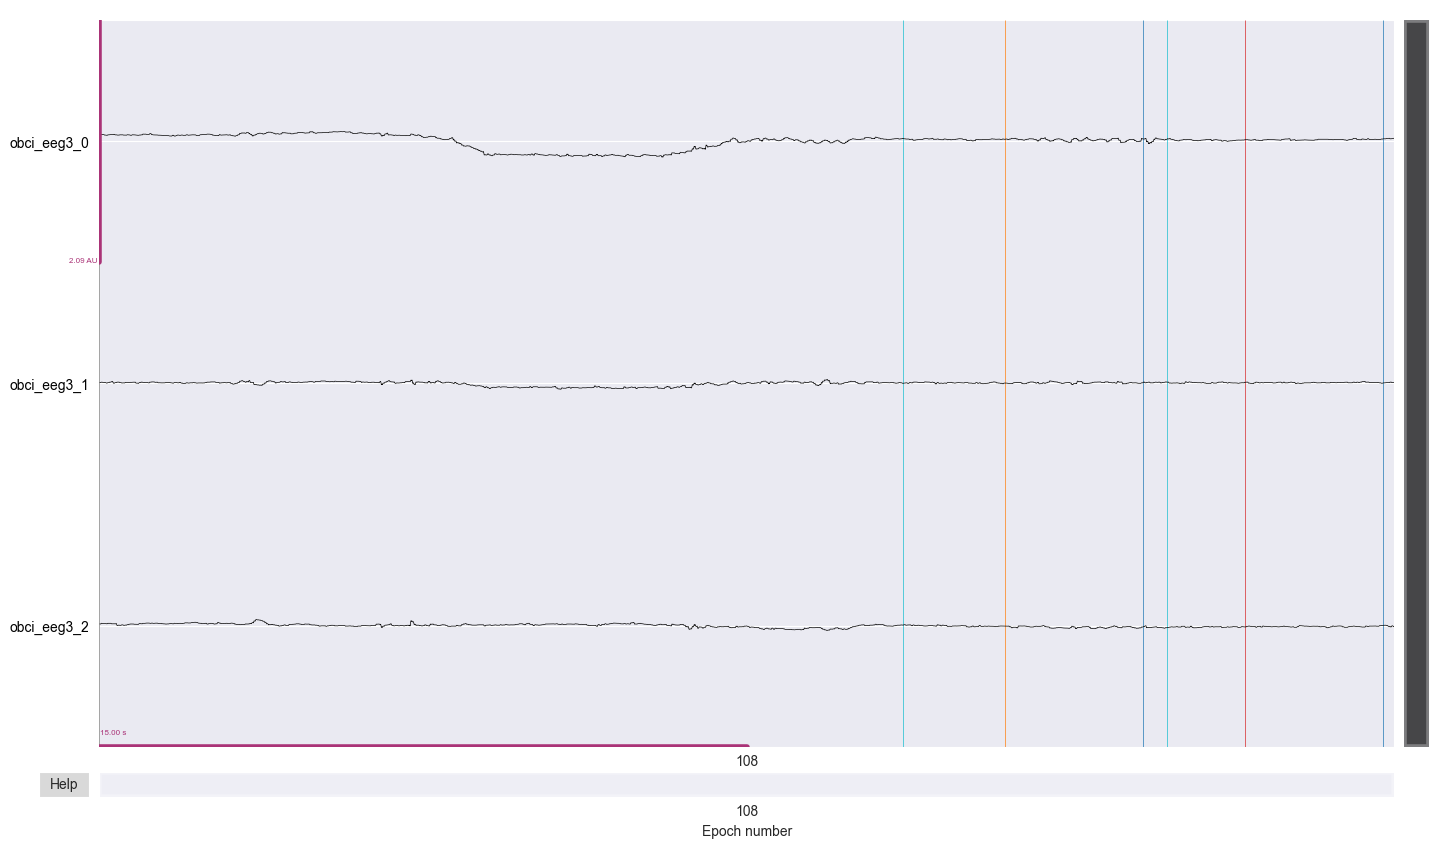

second movement


/var/folders/k_/m6hrxyv11xlfgj_0mzzyg_sc0000gp/T/ipykernel_7272/4199023731.py:5: RuntimeWarning: More events than default colors available. You should pass a list of unique colors.
  move_epochs[1].plot( picks='all', events=new_events)


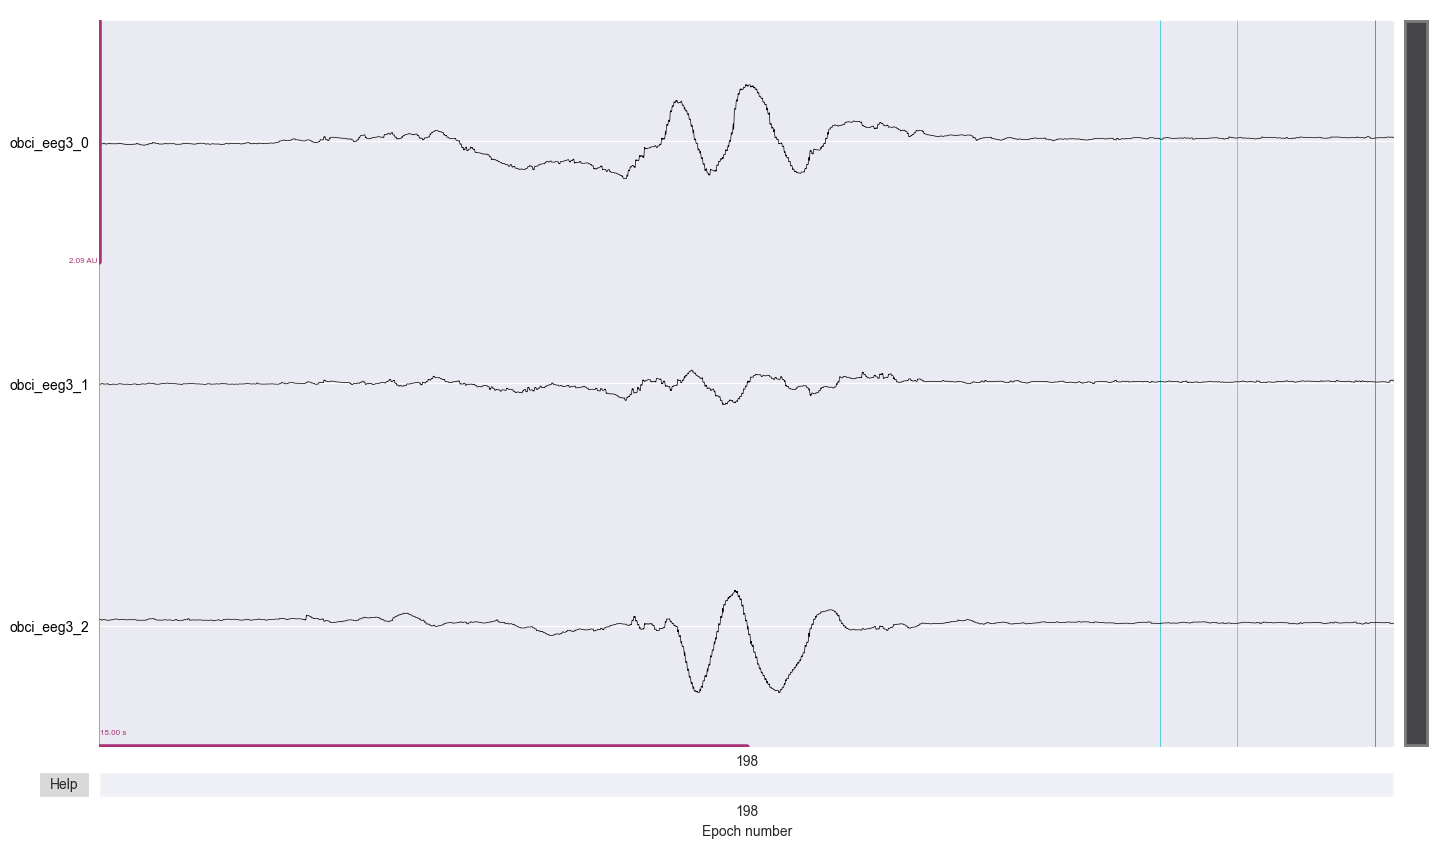

In [75]:
print("first movement")
move_epochs[0].plot( picks='all', events=new_events)
plt.show()
print("second movement")
move_epochs[1].plot( picks='all', events=new_events)
plt.show()

SSVEP1
    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs...


/Users/alkalisk/miniforge3/envs/BCI/lib/python3.10/site-packages/mne/viz/utils.py:165: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


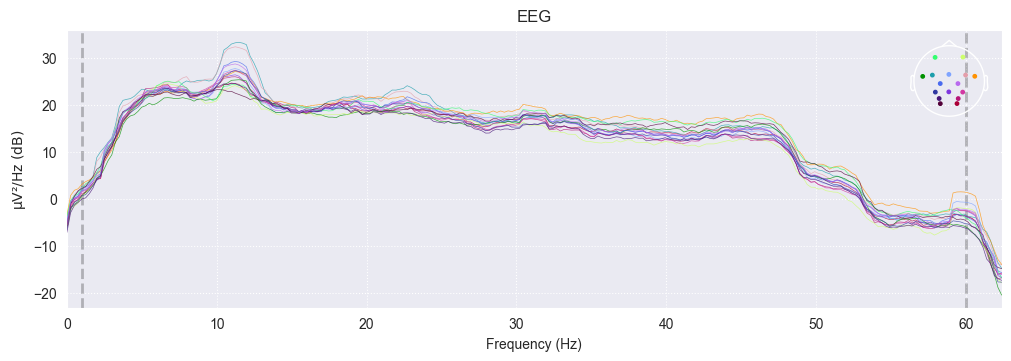

SSVEP2
    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs...


/Users/alkalisk/miniforge3/envs/BCI/lib/python3.10/site-packages/mne/viz/utils.py:165: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


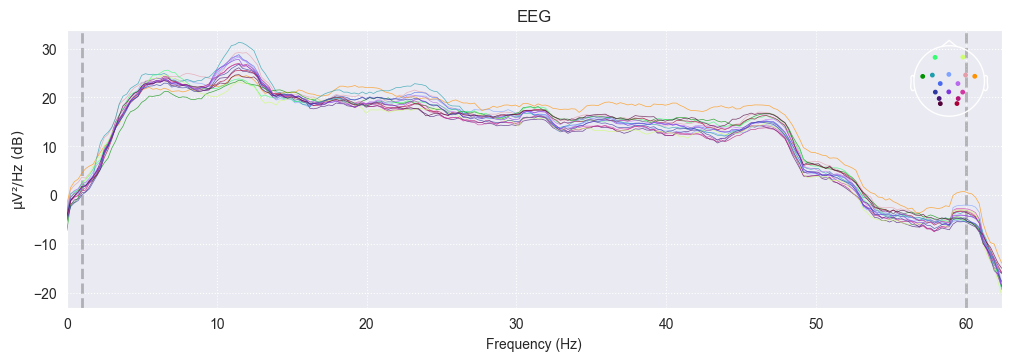

SSVEP3
    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs...


/Users/alkalisk/miniforge3/envs/BCI/lib/python3.10/site-packages/mne/viz/utils.py:165: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


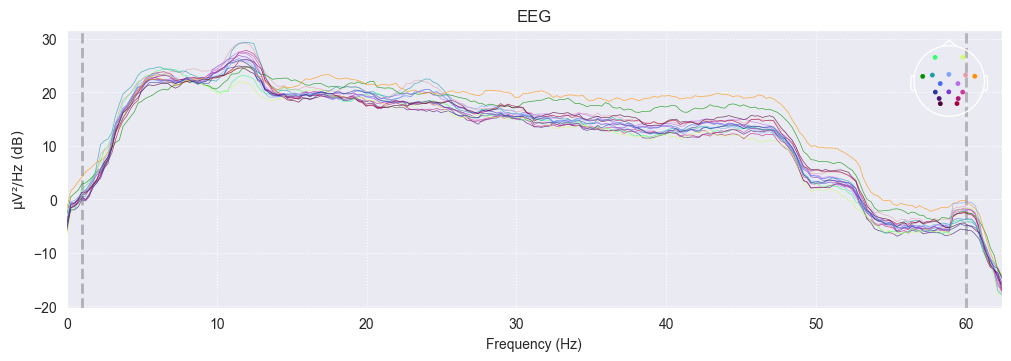

In [76]:
print('SSVEP1')
trial_epochs['SSVEP_1'].compute_psd().plot()
plt.show()
print('SSVEP2')
trial_epochs['SSVEP_2'].compute_psd().plot()
plt.show()
print('SSVEP3')
trial_epochs['SSVEP_3'].compute_psd().plot()
plt.show()
plt.clf()

In [77]:
from mne.preprocessing import ICA
from mne_icalabel import label_components

ica_clean = ICA(
    n_components=16,
    max_iter="auto",
    method="infomax",
    random_state=97,
    fit_params=dict(extended=True),
)

ic_labels = []
for i in [raw_phase1, raw_phase2, raw_phase3]:
    ica_clean.fit(i)
    ic_labels_clean = label_components(i, ica_clean, method="iclabel")
    ic_labels.append(ic_labels_clean)

Fitting ICA to data using 16 channels (please be patient, this may take a while)
Selecting by number: 16 components
Computing Extended Infomax ICA
Fitting ICA took 8.5s.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/var/folders/k_/m6hrxyv11xlfgj_0mzzyg_sc0000gp/T/ipykernel_7272/1383763662.py:15: RuntimeWarning: The provided Raw instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  ic_labels_clean = label_components(i, ica_clean, method="iclabel")
/var/folders/k_/m6hrxyv11xlfgj_0mzzyg_sc0000gp/T/ipykernel_7272/1383763662.py:15: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels_clean = label_components(i, ica_clean, method="iclabel")


Fitting ICA to data using 16 channels (please be patient, this may take a while)
Selecting by number: 16 components
Computing Extended Infomax ICA
Fitting ICA took 4.3s.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/var/folders/k_/m6hrxyv11xlfgj_0mzzyg_sc0000gp/T/ipykernel_7272/1383763662.py:15: RuntimeWarning: The provided Raw instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  ic_labels_clean = label_components(i, ica_clean, method="iclabel")
/var/folders/k_/m6hrxyv11xlfgj_0mzzyg_sc0000gp/T/ipykernel_7272/1383763662.py:15: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels_clean = label_components(i, ica_clean, method="iclabel")


Fitting ICA to data using 16 channels (please be patient, this may take a while)
Selecting by number: 16 components
Computing Extended Infomax ICA
Fitting ICA took 3.9s.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/var/folders/k_/m6hrxyv11xlfgj_0mzzyg_sc0000gp/T/ipykernel_7272/1383763662.py:15: RuntimeWarning: The provided Raw instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  ic_labels_clean = label_components(i, ica_clean, method="iclabel")
/var/folders/k_/m6hrxyv11xlfgj_0mzzyg_sc0000gp/T/ipykernel_7272/1383763662.py:15: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels_clean = label_components(i, ica_clean, method="iclabel")


In [78]:
for idx,result in enumerate(ic_labels):
    print(f'Phase {idx+1}')
    print(result['labels'])
    print(result['y_pred_proba'])

Phase 1
['heart beat', 'brain', 'heart beat', 'brain', 'brain', 'heart beat', 'brain', 'heart beat', 'heart beat', 'brain', 'brain', 'heart beat', 'heart beat', 'brain', 'heart beat', 'heart beat']
[0.99505055 0.99473983 0.5868654  0.99096036 0.992719   0.9189582
 0.62222564 0.899509   0.7803012  0.8297407  0.46526316 0.9210195
 0.34852213 0.641235   0.86498165 0.555824  ]
Phase 2
['heart beat', 'heart beat', 'brain', 'heart beat', 'brain', 'brain', 'brain', 'heart beat', 'heart beat', 'brain', 'brain', 'heart beat', 'heart beat', 'brain', 'heart beat', 'heart beat']
[0.55956817 0.8783581  0.55347645 0.95887136 0.6622731  0.93521255
 0.8595264  0.5177152  0.540455   0.94852245 0.6256794  0.73123133
 0.4742136  0.749834   0.90532094 0.7363262 ]
Phase 3
['brain', 'brain', 'heart beat', 'brain', 'heart beat', 'brain', 'heart beat', 'brain', 'brain', 'brain', 'heart beat', 'brain', 'heart beat', 'brain', 'heart beat', 'brain']
[0.50116754 0.8630825  0.9939196  0.9814197  0.5312469  0.70908

In [79]:
from asrpy import ASR

raw_phase1_asr = raw_phase1.copy()
raw_phase2_asr = raw_phase2.copy()
raw_phase3_asr = raw_phase3.copy()

# Apply the ASR
asr = ASR(sfreq=125, cutoff=2.5)
for i in [raw_phase1_asr, raw_phase2_asr, raw_phase3_asr]:
    asr.fit(i)
    i = asr.transform(i)


asr_ic_labels = []
for i in [raw_phase1_asr, raw_phase2_asr, raw_phase3_asr]:
    ica_clean.fit(i)
    ic_labels_clean = label_components(i, ica_clean, method="iclabel")
    asr_ic_labels.append(ic_labels_clean)

Fitting ICA to data using 16 channels (please be patient, this may take a while)
Selecting by number: 16 components
Computing Extended Infomax ICA
Fitting ICA took 8.1s.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/var/folders/k_/m6hrxyv11xlfgj_0mzzyg_sc0000gp/T/ipykernel_7272/1499195397.py:17: RuntimeWarning: The provided Raw instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  ic_labels_clean = label_components(i, ica_clean, method="iclabel")
/var/folders/k_/m6hrxyv11xlfgj_0mzzyg_sc0000gp/T/ipykernel_7272/1499195397.py:17: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels_clean = label_components(i, ica_clean, method="iclabel")


Fitting ICA to data using 16 channels (please be patient, this may take a while)
Selecting by number: 16 components
Computing Extended Infomax ICA
Fitting ICA took 4.5s.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/var/folders/k_/m6hrxyv11xlfgj_0mzzyg_sc0000gp/T/ipykernel_7272/1499195397.py:17: RuntimeWarning: The provided Raw instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  ic_labels_clean = label_components(i, ica_clean, method="iclabel")
/var/folders/k_/m6hrxyv11xlfgj_0mzzyg_sc0000gp/T/ipykernel_7272/1499195397.py:17: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels_clean = label_components(i, ica_clean, method="iclabel")


Fitting ICA to data using 16 channels (please be patient, this may take a while)
Selecting by number: 16 components
Computing Extended Infomax ICA
Fitting ICA took 3.8s.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/var/folders/k_/m6hrxyv11xlfgj_0mzzyg_sc0000gp/T/ipykernel_7272/1499195397.py:17: RuntimeWarning: The provided Raw instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  ic_labels_clean = label_components(i, ica_clean, method="iclabel")
/var/folders/k_/m6hrxyv11xlfgj_0mzzyg_sc0000gp/T/ipykernel_7272/1499195397.py:17: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels_clean = label_components(i, ica_clean, method="iclabel")


In [80]:
for idx,result in enumerate(asr_ic_labels):
    print(f'Phase {idx+1}')
    print(result['labels'])
    print(result['y_pred_proba'])

Phase 1
['heart beat', 'brain', 'heart beat', 'brain', 'brain', 'heart beat', 'brain', 'heart beat', 'heart beat', 'brain', 'brain', 'heart beat', 'heart beat', 'brain', 'heart beat', 'heart beat']
[0.99505055 0.99473983 0.5868654  0.99096036 0.992719   0.9189582
 0.62222564 0.899509   0.7803012  0.8297407  0.46526316 0.9210195
 0.34852213 0.641235   0.86498165 0.555824  ]
Phase 2
['heart beat', 'heart beat', 'brain', 'heart beat', 'brain', 'brain', 'brain', 'heart beat', 'heart beat', 'brain', 'brain', 'heart beat', 'heart beat', 'brain', 'heart beat', 'heart beat']
[0.55956817 0.8783581  0.55347645 0.95887136 0.6622731  0.93521255
 0.8595264  0.5177152  0.540455   0.94852245 0.6256794  0.73123133
 0.4742136  0.749834   0.90532094 0.7363262 ]
Phase 3
['brain', 'brain', 'heart beat', 'brain', 'heart beat', 'brain', 'heart beat', 'brain', 'brain', 'brain', 'heart beat', 'brain', 'heart beat', 'brain', 'heart beat', 'brain']
[0.50116754 0.8630825  0.9939196  0.9814197  0.5312469  0.70908

In [85]:
from scipy import stats

similarity_list= []
for i in ([raw_phase1,raw_phase1_asr], 
          [raw_phase2,raw_phase2_asr], 
          [raw_phase3,raw_phase3_asr]):
    cov = np.cov(i[0].get_data().reshape(-1),i[1].get_data().reshape(-1))
    print(cov)



[[3.71290233e-11 3.71290233e-11]
 [3.71290233e-11 3.71290233e-11]]
[[4.50929464e-11 4.50929464e-11]
 [4.50929464e-11 4.50929464e-11]]
[[4.81596269e-11 4.81596269e-11]
 [4.81596269e-11 4.81596269e-11]]


In [100]:
new_event_dict

{'RH_1': 7,
 'RH_2': 107,
 'RH_3': 207,
 'SSVEP_1': 9,
 'SSVEP_2': 109,
 'SSVEP_3': 209,
 'idle_1': 19,
 'idle_2': 119,
 'idle_3': 219}

In [104]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, ShuffleSplit
def compare_csp(epoch, label1, label2, n_components=4):
    epochs_train = epoch[label1,label2].copy().crop(tmin=1, tmax=2.5)
    labels = []
    for i in epoch[label1,label2].events[:, -1]:
        if i == new_event_dict[label1]:
            labels.append(1)
        else:
            labels.append(0)
    # Define a monte-carlo cross-validation generator (reduce variance):
    scores = []
    epochs_data = epoch[label1,label2].get_data()
    epochs_data_train = epochs_train.get_data()
    cv = ShuffleSplit(5, test_size=0.2, random_state=42)
    cv_split = cv.split(epochs_data_train)
    
    # Assemble a classifier
    lda = LinearDiscriminantAnalysis()
    csp = CSP(n_components=n_components, reg=None, log=True, norm_trace=False)
    
    # Use scikit-learn Pipeline with cross_val_score function
    clf = Pipeline([("CSP", csp), ("LDA", lda)])
    scores = cross_val_score(clf, epochs_data_train, labels, cv=cv, n_jobs=None)
    
    # Printing the results
    class_balance = np.mean(labels == labels[0])
    class_balance = max(class_balance, 1.0 - class_balance)
    print(
        "Classification accuracy: %f / Chance level: %f" % (np.mean(scores), class_balance)
    )
    
    # plot CSP patterns estimated on full data for visualization
    csp.fit_transform(epochs_data, labels)
    
    csp.plot_patterns(trial_epochs['RH_1','idle_1'].info, ch_type="eeg", units="Patterns (AU)", size=1.5)
    plt.show()
    plt.clf()
    
    return np.mean(scores)
    

Computing rank from data with rank=None


/var/folders/k_/m6hrxyv11xlfgj_0mzzyg_sc0000gp/T/ipykernel_7272/4186263932.py:14: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  epochs_data = epoch[label1,label2].get_data()
/var/folders/k_/m6hrxyv11xlfgj_0mzzyg_sc0000gp/T/ipykernel_7272/4186263932.py:15: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  epochs_data_train = epochs_train.get_data()


    Using tolerance 2.6e-06 (2.2e-16 eps * 16 dim * 7.2e+08  max singular value)
    Estimated rank (mag): 16
    MAG: rank 16 computed from 16 data channels with 0 projectors
Reducing data rank from 16 -> 16
Estimating covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 2.4e-06 (2.2e-16 eps * 16 dim * 6.8e+08  max singular value)
    Estimated rank (mag): 16
    MAG: rank 16 computed from 16 data channels with 0 projectors
Reducing data rank from 16 -> 16
Estimating covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 2.4e-06 (2.2e-16 eps * 16 dim * 6.7e+08  max singular value)
    Estimated rank (mag): 16
    MAG: rank 16 computed from 16 data channels with 0 projectors
Reducing data rank from 16 -> 16
Estimating covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 2.3e-06 (2.2e-16 eps * 16 dim * 6.4e+08  max singular value)
    Estimated rank (mag): 16
    MAG: ra

<Figure size 640x480 with 0 Axes>

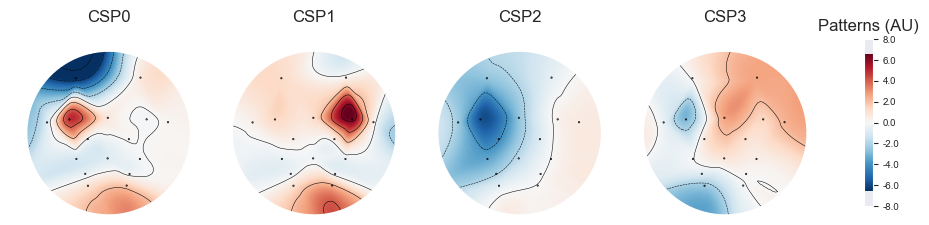

Computing rank from data with rank=None


/var/folders/k_/m6hrxyv11xlfgj_0mzzyg_sc0000gp/T/ipykernel_7272/4186263932.py:14: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  epochs_data = epoch[label1,label2].get_data()
/var/folders/k_/m6hrxyv11xlfgj_0mzzyg_sc0000gp/T/ipykernel_7272/4186263932.py:15: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  epochs_data_train = epochs_train.get_data()


    Using tolerance 2.4e-06 (2.2e-16 eps * 16 dim * 6.8e+08  max singular value)
    Estimated rank (mag): 16
    MAG: rank 16 computed from 16 data channels with 0 projectors
Reducing data rank from 16 -> 16
Estimating covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 3e-06 (2.2e-16 eps * 16 dim * 8.4e+08  max singular value)
    Estimated rank (mag): 16
    MAG: rank 16 computed from 16 data channels with 0 projectors
Reducing data rank from 16 -> 16
Estimating covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 2.2e-06 (2.2e-16 eps * 16 dim * 6.3e+08  max singular value)
    Estimated rank (mag): 16
    MAG: rank 16 computed from 16 data channels with 0 projectors
Reducing data rank from 16 -> 16
Estimating covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 3.1e-06 (2.2e-16 eps * 16 dim * 8.8e+08  max singular value)
    Estimated rank (mag): 16
    MAG: rank

<Figure size 640x480 with 0 Axes>

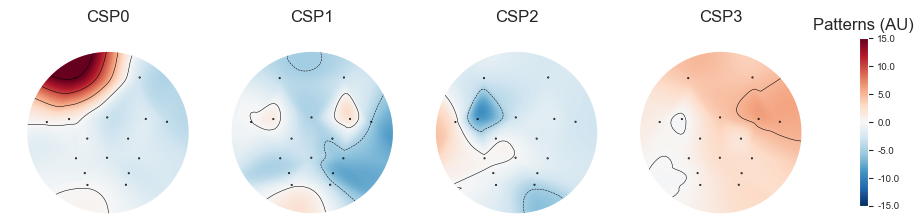

Computing rank from data with rank=None


/var/folders/k_/m6hrxyv11xlfgj_0mzzyg_sc0000gp/T/ipykernel_7272/4186263932.py:14: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  epochs_data = epoch[label1,label2].get_data()
/var/folders/k_/m6hrxyv11xlfgj_0mzzyg_sc0000gp/T/ipykernel_7272/4186263932.py:15: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  epochs_data_train = epochs_train.get_data()


    Using tolerance 2.4e-06 (2.2e-16 eps * 16 dim * 6.8e+08  max singular value)
    Estimated rank (mag): 16
    MAG: rank 16 computed from 16 data channels with 0 projectors
Reducing data rank from 16 -> 16
Estimating covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 2.6e-06 (2.2e-16 eps * 16 dim * 7.4e+08  max singular value)
    Estimated rank (mag): 16
    MAG: rank 16 computed from 16 data channels with 0 projectors
Reducing data rank from 16 -> 16
Estimating covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 2.3e-06 (2.2e-16 eps * 16 dim * 6.6e+08  max singular value)
    Estimated rank (mag): 16
    MAG: rank 16 computed from 16 data channels with 0 projectors
Reducing data rank from 16 -> 16
Estimating covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 3e-06 (2.2e-16 eps * 16 dim * 8.5e+08  max singular value)
    Estimated rank (mag): 16
    MAG: rank

<Figure size 640x480 with 0 Axes>

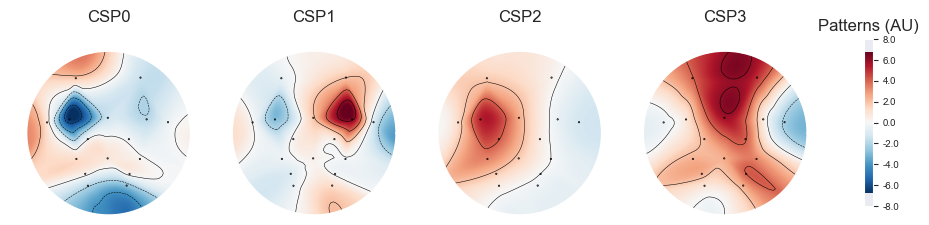

[1.0, 1.0, 1.0]


In [105]:
scores = []
scores.append(compare_csp(trial_epochs,'RH_1','idle_1'))
scores.append(compare_csp(trial_epochs,'RH_2','idle_2'))
scores.append(compare_csp(trial_epochs,'RH_3','idle_3'))
print(scores)



In [131]:
from sklearn.cross_decomposition import CCA
from scipy.stats import pearsonr
import warnings
import scipy.signal
import numpy as np

def cca_reference(list_freqs, fs, num_smpls, num_harms=3):
    num_freqs = len(list_freqs)
    tidx = np.arange(1, num_smpls + 1) / fs  # time index

    y_ref = np.zeros((num_freqs, 2 * num_harms, num_smpls))
    for freq_i in range(num_freqs):
        tmp = []
        for harm_i in range(1, num_harms + 1):
            stim_freq = list_freqs[freq_i]  # in HZ
            # Sin and Cos
            tmp.extend([np.sin(2 * np.pi * tidx * harm_i * stim_freq),
                        np.cos(2 * np.pi * tidx * harm_i * stim_freq)])
        y_ref[freq_i] = tmp  # 2*num_harms because include both sin and cos

    return y_ref

def filterbank(eeg, fs, idx_fb):
    if idx_fb == None:
        warnings.warn('stats:filterbank:MissingInput ' \
                      + 'Missing filter index. Default value (idx_fb = 0) will be used.')
        idx_fb = 0
    elif (idx_fb < 0 or 9 < idx_fb):
        raise ValueError('stats:filterbank:InvalidInput ' \
                         + 'The number of sub-bands must be 0 <= idx_fb <= 9.')

    if (len(eeg.shape) == 2):
        num_chans = eeg.shape[0]
        num_trials = 1
    else:
        num_chans, _, num_trials = eeg.shape

    # Nyquist Frequency = Fs/2N
    Nq = fs / 2

    passband = [6, 8, 10, 16, 22, 28, 34, 40]
    stopband = [4, 6, 6, 10, 16, 22, 28, 34]
    Wp = [passband[idx_fb] / Nq, 50 / Nq]
    Ws = [stopband[idx_fb] / Nq, 60 / Nq]
    [N, Wn] = scipy.signal.cheb1ord(Wp, Ws, 3, 40)  # band pass filter StopBand=[Ws(1)~Ws(2)] PassBand=[Wp(1)~Wp(2)]
    [B, A] = scipy.signal.cheby1(N, 0.5, Wn, 'bandpass')  # Wn passband edge frequency

    y = np.zeros(eeg.shape)
    if (num_trials == 1):
        for ch_i in range(num_chans):
            # apply filter, zero phass filtering by applying a linear filter twice, once forward and once backwards.
            # to match matlab result we need to change padding length
            y[ch_i, :] = scipy.signal.filtfilt(B, A, eeg[ch_i, :], padtype='odd', padlen=3 * (max(len(B), len(A)) - 1))

    else:
        for trial_i in range(num_trials):
            for ch_i in range(num_chans):
                y[ch_i, :, trial_i] = scipy.signal.filtfilt(B, A, eeg[ch_i, :, trial_i], padtype='odd',
                                                            padlen=3 * (max(len(B), len(A)) - 1))

    return y


def fbcca(eeg, list_freqs, fs, num_harms=3, num_fbs=5):
    fb_coefs = np.power(np.arange(1, num_fbs + 1), (-1.25)) + 0.25

    num_targs, _, num_smpls = eeg.shape  # 40 taget (means 40 fre-phase combination that we want to predict)
    y_ref = cca_reference(list_freqs, fs, num_smpls, num_harms)
    cca = CCA(n_components=1)  # initilize CCA

    # result matrix
    r = np.zeros((num_fbs, num_targs))
    results = np.zeros(num_targs)

    for targ_i in range(num_targs):
        test_tmp = np.squeeze(eeg[targ_i, :, :])  # deal with one target a time
        for fb_i in range(num_fbs):  # filter bank number, deal with different filter bank
            testdata = filterbank(test_tmp, fs, fb_i)  # data after filtering
            for class_i in range(num_targs):
                refdata = np.squeeze(y_ref[class_i, :, :])  # pick corresponding freq target reference signal
                test_C, ref_C = cca.fit_transform(testdata.T, refdata.T)
                # len(row) = len(observation), len(column) = variables of each observation
                # number of rows should be the same, so need transpose here
                # output is the highest correlation linear combination of two sets
                r_tmp, _ = pearsonr(np.squeeze(test_C),
                                    np.squeeze(ref_C))  # return r and p_value, use np.squeeze to adapt the API
                r[fb_i, class_i] = r_tmp

        rho = np.dot(fb_coefs, r)  # weighted sum of r from all different filter banks' result
        tau = np.argmax(rho)  # get maximum from the target as the final predict (get the index)
        results[targ_i] = tau  # index indicate the maximum(most possible) target
    return results

def fbcca_realtime(data, list_freqs, fs, num_harms=3, num_fbs=5):
    fb_coefs = np.power(np.arange(1, num_fbs + 1), (-1.25)) + 0.25

    num_targs = len(list_freqs)
    _, num_smpls = data.shape

    y_ref = cca_reference(list_freqs, fs, num_smpls, num_harms)
    cca = CCA(n_components=1)  # initialize CCA

    # result matrix
    r = np.zeros((num_fbs, num_targs))

    for fb_i in range(num_fbs):  # filter bank number, deal with different filter bank
        testdata = filterbank(data, fs, fb_i)  # data after filtering
        for class_i in range(num_targs):
            refdata = np.squeeze(y_ref[class_i, :, :])  # pick corresponding freq target reference signal
            test_C, ref_C = cca.fit_transform(testdata.T, refdata.T)
            r_tmp, _ = pearsonr(np.squeeze(test_C), np.squeeze(ref_C))  # return r and p_value
            if r_tmp == np.nan:
                r_tmp = 0
            r[fb_i, class_i] = r_tmp

    rho = np.dot(fb_coefs, r)  # weighted sum of r from all different filter banks' result
    #print(rho)  # print out the correlation
    result = np.argmax(rho)  # get maximum from the target as the final predict (get the index), and index indicates the maximum entry(most possible target)
    return rho

In [134]:
#SSVEP_parameter
list_freqs = [6,8,12]
num_harms = 3
num_fbs = 5

mean_score = []
for i in [trial_epochs['SSVEP_1'],trial_epochs['SSVEP_2'],trial_epochs['SSVEP_3']]:
    score = []
    for j in range(10):
        score.append(fbcca_realtime(i[j].get_data()[0], list_freqs, 125,num_harms,num_fbs))
    
    mean_score.append(np.mean(score))
    
print(mean_score)

/var/folders/k_/m6hrxyv11xlfgj_0mzzyg_sc0000gp/T/ipykernel_7272/1353720446.py:9: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  score.append(fbcca_realtime(i[j].get_data()[0], list_freqs, 125,num_harms,num_fbs))
/var/folders/k_/m6hrxyv11xlfgj_0mzzyg_sc0000gp/T/ipykernel_7272/1353720446.py:9: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  score.append(fbcca_realtime(i[j].get_data()[0], list_freqs, 125,num_harms,num_fbs))
/var/folders/k_/m6hrxyv11xlfgj_0mzzyg_sc0000gp/T/ipykernel_7272/1353720446.py:9: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  score.append(fbcca_realtime(i[j].get_data()[0], list_freqs, 125,num_harms,num_fbs))
/var/folders/k_/m6hrxyv11xlfgj_0mzzyg_sc0000gp/T/ipykernel_7272/1353720446.py:9: FutureW

[1.2402653  1.20810149 1.31435086]


/var/folders/k_/m6hrxyv11xlfgj_0mzzyg_sc0000gp/T/ipykernel_7272/1353720446.py:9: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  score.append(fbcca_realtime(i[j].get_data()[0], list_freqs, 125,num_harms,num_fbs))
/var/folders/k_/m6hrxyv11xlfgj_0mzzyg_sc0000gp/T/ipykernel_7272/1353720446.py:9: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  score.append(fbcca_realtime(i[j].get_data()[0], list_freqs, 125,num_harms,num_fbs))
/var/folders/k_/m6hrxyv11xlfgj_0mzzyg_sc0000gp/T/ipykernel_7272/1353720446.py:9: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  score.append(fbcca_realtime(i[j].get_data()[0], list_freqs, 125,num_harms,num_fbs))
/var/folders/k_/m6hrxyv11xlfgj_0mzzyg_sc0000gp/T/ipykernel_7272/1353720446.py:9: FutureW

[1.40036016 1.27866154 1.48971376]


/var/folders/k_/m6hrxyv11xlfgj_0mzzyg_sc0000gp/T/ipykernel_7272/1353720446.py:9: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  score.append(fbcca_realtime(i[j].get_data()[0], list_freqs, 125,num_harms,num_fbs))
/var/folders/k_/m6hrxyv11xlfgj_0mzzyg_sc0000gp/T/ipykernel_7272/1353720446.py:9: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  score.append(fbcca_realtime(i[j].get_data()[0], list_freqs, 125,num_harms,num_fbs))
/var/folders/k_/m6hrxyv11xlfgj_0mzzyg_sc0000gp/T/ipykernel_7272/1353720446.py:9: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  score.append(fbcca_realtime(i[j].get_data()[0], list_freqs, 125,num_harms,num_fbs))
/var/folders/k_/m6hrxyv11xlfgj_0mzzyg_sc0000gp/T/ipykernel_7272/1353720446.py:9: FutureW

[1.37065333 1.32482737 1.46589268]


In [146]:
from scipy.stats import pearsonr
print('SSVEP vs idle')
for phase in [['SSVEP_1','idle_1'],['SSVEP_2','idle_2'],['SSVEP_3','idle_3']]:
    array1 = trial_epochs[phase[0]].average().get_data().reshape(-1)
    array2 = trial_epochs[phase[1]].average().get_data().reshape(-1)
    corr, _ = pearsonr(array1, array2)
    print(corr)
print('RH vs idle')
for phase in [['RH_1','idle_1'],['RH_2','idle_2'],['RH_3','idle_3']]:
    array1 = trial_epochs[phase[0]].average().get_data().reshape(-1)
    array2 = trial_epochs[phase[1]].average().get_data().reshape(-1)
    corr, _ = pearsonr(array1, array2)
    print(corr)
print('RH vs SSVEP')
for phase in [['RH_1','SSVEP_1'],['RH_2','SSVEP_2'],['RH_3','SSVEP_3']]:
    array1 = trial_epochs[phase[0]].average().get_data().reshape(-1)
    array2 = trial_epochs[phase[1]].average().get_data().reshape(-1)
    corr, _ = pearsonr(array1, array2)
    print(corr)


SSVEP vs idle
-0.07675974592406111
0.02832375268118642
-0.009844931076943411
RH vs idle
-0.06171237684490738
0.0032811921358990477
-0.02822197614209912
RH vs SSVEP
-0.07724442962100571
-0.021441911955190622
-0.08818445157557303
